# Casino Challenge — Multi-Armed Bandits Reflection Notebook

## Student Information
- **Name:** Rohit Iyer
- **Student ID:** 8993045

## Notebook Goal
This notebook recreates and analyzes the two workshop competitions:

1. **Stationary Casino**
2. **Non-Stationary Casino**

It focuses on:
- generating CSV summaries from both rounds
- understanding the **exploration–exploitation trade-off**
- explaining **why ε matters**
- showing **why constant-α is useful in non-stationary settings**
- documenting reflections and visualizations in a clean notebook format

This notebook is my own write-up based on the workshop structure, but organized as a standalone reflection notebook.

## 1. Setup

We import the libraries used for simulation, analysis, and plotting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Helper Functions

We reproduce the core workshop bandit logic in code so the notebook is self-contained.

In [2]:
def make_stationary_bandit(n_arms=10, seed=42):
    rng = np.random.default_rng(seed)
    return rng.random(n_arms)

def epsilon_greedy(true_means, steps=2000, epsilon=0.1, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    optimal_arm = int(np.argmax(true_means))
    optimal_flags = np.zeros(steps, dtype=int)

    for t in range(steps):
        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))

        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]

        rewards[t] = r
        actions[t] = a
        optimal_flags[t] = int(a == optimal_arm)

    return rewards, actions, Q, N, optimal_flags

def epsilon_greedy_decaying(true_means, steps=2000, eps_start=0.5, eps_end=0.05, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    optimal_arm = int(np.argmax(true_means))
    optimal_flags = np.zeros(steps, dtype=int)
    eps_track = np.zeros(steps, dtype=float)

    for t in range(steps):
        epsilon = eps_end + (eps_start - eps_end) * max(0, (steps - 1 - t)) / max(1, steps - 1)
        eps_track[t] = epsilon

        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))

        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]

        rewards[t] = r
        actions[t] = a
        optimal_flags[t] = int(a == optimal_arm)

    return rewards, actions, Q, N, optimal_flags, eps_track

def step_drift(means, drift_scale=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    means = means + rng.normal(0, drift_scale, size=means.shape)
    return np.clip(means, 0.0, 1.0)

def epsilon_greedy_constant_alpha(steps=3000, n_arms=10, eps=0.1, alpha=0.1, seed_env=2025, seed_agent=None, drift_scale=0.01):
    rng_env = np.random.default_rng(seed_env)
    rng_agent = np.random.default_rng(seed_agent)

    means = rng_env.random(n_arms)
    Q = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    means_history = np.zeros((steps, n_arms), dtype=float)

    for t in range(steps):
        means_history[t] = means

        if rng_agent.random() < eps:
            a = rng_agent.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))

        r = 1.0 if rng_env.random() < means[a] else 0.0
        Q[a] = Q[a] + alpha * (r - Q[a])

        rewards[t] = r
        actions[t] = a
        means = step_drift(means, drift_scale=drift_scale, rng=rng_env)

    optimal_flags = (actions == means_history.argmax(axis=1)).astype(int)
    return rewards, actions, Q, optimal_flags

## 3. Round 1 — Stationary Casino

In the stationary casino, each arm has a fixed hidden reward probability.

This means:
- the best arm does **not change**
- the main challenge is balancing:
  - **exploration**: trying enough arms to find the best one
  - **exploitation**: repeatedly selecting the best estimated arm

We compare several ε values plus a decaying-ε strategy.

In [3]:
TRUE_MEANS = make_stationary_bandit(seed=42)
TRUE_MEANS

array([0.77395605, 0.43887844, 0.85859792, 0.69736803, 0.09417735,
       0.97562235, 0.7611397 , 0.78606431, 0.12811363, 0.45038594])

In [4]:
stationary_rows = []

for eps in [0.0, 0.05, 0.1, 0.2, 0.5]:
    totals, avg100, optrate = [], [], []
    for s in range(10):
        rewards, actions, Q, N, optimal = epsilon_greedy(TRUE_MEANS, steps=2000, epsilon=eps, seed=100+s)
        totals.append(rewards.sum())
        avg100.append(rewards[-100:].mean())
        optrate.append(optimal.mean())

    stationary_rows.append({
        "competition": "Stationary Casino",
        "strategy": "epsilon_greedy",
        "epsilon": eps,
        "steps": 2000,
        "runs": 10,
        "mean_total_reward": float(np.mean(totals)),
        "std_total_reward": float(np.std(totals)),
        "mean_last100_reward": float(np.mean(avg100)),
        "mean_optimal_action_rate": float(np.mean(optrate))
    })

totals, avg100, optrate = [], [], []
for s in range(10):
    rewards, actions, Q, N, optimal, eps_track = epsilon_greedy_decaying(TRUE_MEANS, steps=2000, eps_start=0.5, eps_end=0.05, seed=200+s)
    totals.append(rewards.sum())
    avg100.append(rewards[-100:].mean())
    optrate.append(optimal.mean())

stationary_rows.append({
    "competition": "Stationary Casino",
    "strategy": "epsilon_greedy_decaying",
    "epsilon": "0.5->0.05",
    "steps": 2000,
    "runs": 10,
    "mean_total_reward": float(np.mean(totals)),
    "std_total_reward": float(np.std(totals)),
    "mean_last100_reward": float(np.mean(avg100)),
    "mean_optimal_action_rate": float(np.mean(optrate))
})

stationary_df = pd.DataFrame(stationary_rows)
stationary_df

,competition,strategy,epsilon,steps,runs,mean_total_reward,std_total_reward,mean_last100_reward,mean_optimal_action_rate
0,Stationary Casino,epsilon_greedy,0.0,2000,10,1549.7,17.827226,0.781,0.00000
1,Stationary Casino,epsilon_greedy,0.05,2000,10,1873.2,29.325075,0.957,0.83225
2,Stationary Casino,epsilon_greedy,0.1,2000,10,1840.8,44.278211,0.938,0.79995
3,Stationary Casino,epsilon_greedy,0.2,2000,10,1793.2,16.265300,0.904,0.80440
4,Stationary Casino,epsilon_greedy,0.5,2000,10,1563.9,16.385664,0.791,0.53290
5,Stationary Casino,epsilon_greedy_decaying,0.5->0.05,2000,10,1737.0,18.335757,0.938,0.72310


### Reflection — Why ε Matters in the Stationary Casino

In a stationary problem, the best arm is fixed. If ε is too small, the agent may lock onto a suboptimal arm too early. If ε is too large, the agent keeps wasting pulls on weaker arms.

A moderate ε often works best because it:
- allows enough exploration early
- still exploits the best estimate often enough
- improves the chance of identifying the true best arm

A decaying ε schedule can also work well because:
- it explores more at the beginning
- it gradually shifts toward exploitation once estimates improve

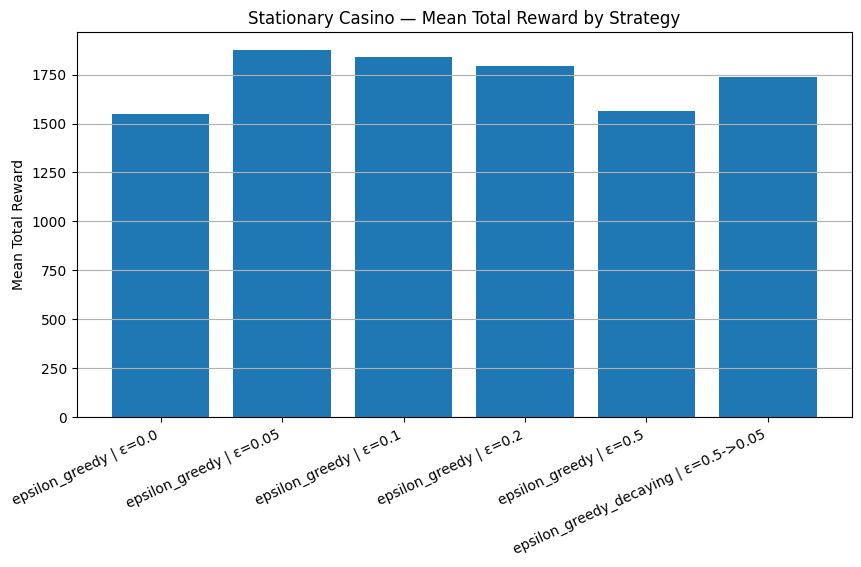

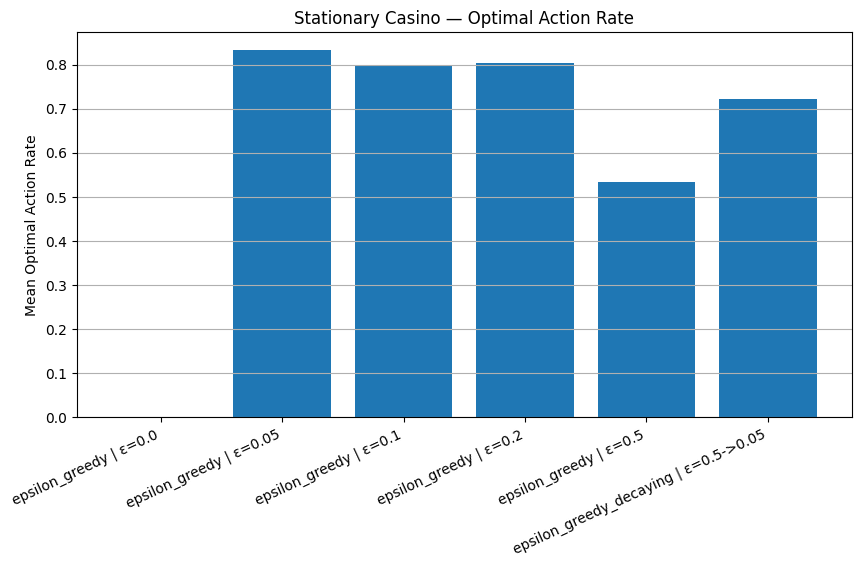

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(stationary_df["strategy"].astype(str) + " | ε=" + stationary_df["epsilon"].astype(str), stationary_df["mean_total_reward"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean Total Reward")
plt.title("Stationary Casino — Mean Total Reward by Strategy")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(stationary_df["strategy"].astype(str) + " | ε=" + stationary_df["epsilon"].astype(str), stationary_df["mean_optimal_action_rate"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean Optimal Action Rate")
plt.title("Stationary Casino — Optimal Action Rate")
plt.grid(True, axis="y")
plt.show()

## 4. Round 2 — Non-Stationary Casino

In the non-stationary casino, the arms drift over time.

This changes the problem completely:
- the best arm can change later
- old reward estimates become stale
- a pure sample average may adapt too slowly

That is why **constant-α** is useful here:
- it gives more weight to recent outcomes
- it helps the agent track changes in arm quality
- it makes the estimate more responsive to drift

In [6]:
nonstationary_rows = []

settings = [
    (0.0, 0.1),
    (0.05, 0.1),
    (0.1, 0.1),
    (0.2, 0.1),
    (0.1, 0.01),
    (0.1, 0.3),
]

for eps, alpha in settings:
    totals, avg100, optrate = [], [], []
    for s in range(10):
        rewards, actions, Q, optimal = epsilon_greedy_constant_alpha(
            steps=3000,
            n_arms=10,
            eps=eps,
            alpha=alpha,
            seed_env=2025,
            seed_agent=500+s,
            drift_scale=0.01
        )
        totals.append(rewards.sum())
        avg100.append(rewards[-100:].mean())
        optrate.append(optimal.mean())

    nonstationary_rows.append({
        "competition": "Non-Stationary Casino",
        "strategy": "epsilon_greedy_constant_alpha",
        "epsilon": eps,
        "alpha": alpha,
        "steps": 3000,
        "runs": 10,
        "mean_total_reward": float(np.mean(totals)),
        "std_total_reward": float(np.std(totals)),
        "mean_last100_reward": float(np.mean(avg100)),
        "mean_optimal_action_rate": float(np.mean(optrate))
    })

nonstationary_df = pd.DataFrame(nonstationary_rows)
nonstationary_df

,competition,strategy,epsilon,alpha,steps,runs,mean_total_reward,std_total_reward,mean_last100_reward,mean_optimal_action_rate
0,Non-Stationary Casino,epsilon_greedy_constant_alpha,0.00,0.10,3000,10,2419.0,0.000000,0.580,0.153333
1,Non-Stationary Casino,epsilon_greedy_constant_alpha,0.05,0.10,3000,10,2598.4,15.704776,0.905,0.275233
2,Non-Stationary Casino,epsilon_greedy_constant_alpha,0.10,0.10,3000,10,2593.6,21.513717,0.877,0.305167
3,Non-Stationary Casino,epsilon_greedy_constant_alpha,0.20,0.10,3000,10,2530.0,19.889696,0.819,0.358800
4,Non-Stationary Casino,epsilon_greedy_constant_alpha,0.10,0.01,3000,10,2354.5,7.500000,0.568,0.148400
5,Non-Stationary Casino,epsilon_greedy_constant_alpha,0.10,0.30,3000,10,2632.7,22.077364,0.850,0.442200


### Reflection — Why Constant-α Helps in Non-Stationary Settings

In a non-stationary setting, the reward process drifts over time. That means the agent should not treat very old observations as equally important as new ones.

Using a constant step size α:
- discounts older information naturally
- makes value estimates adapt faster
- improves tracking when the environment changes

If α is too small:
- updates are too slow
- the agent reacts too late to drift

If α is too large:
- estimates may become noisy
- learning may overreact to recent randomness

A moderate α is usually the best compromise.

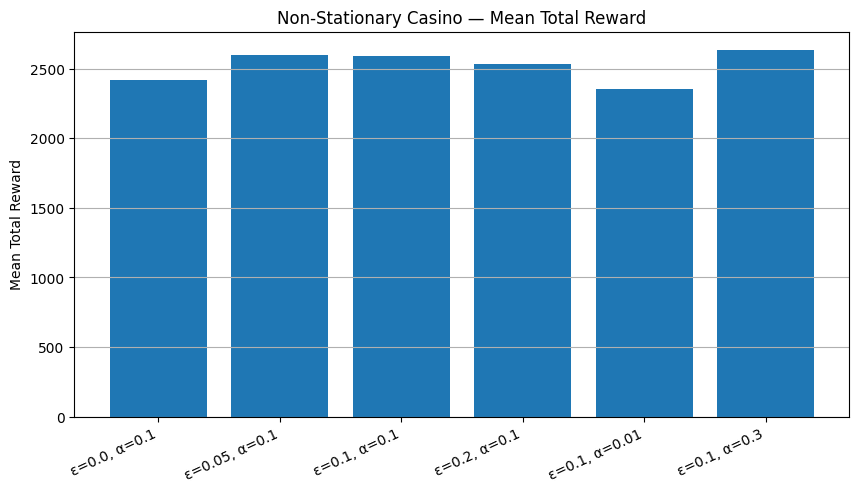

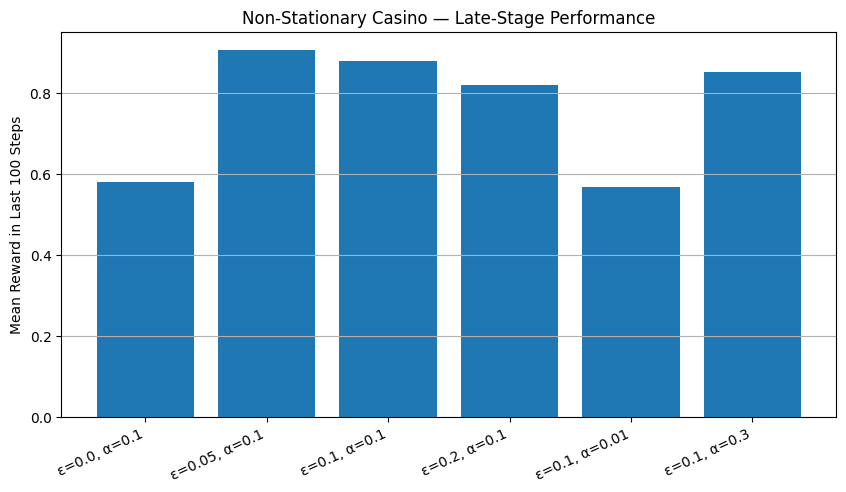

In [7]:
plt.figure(figsize=(10, 5))
labels = [f"ε={row['epsilon']}, α={row['alpha']}" for _, row in nonstationary_df.iterrows()]
plt.bar(labels, nonstationary_df["mean_total_reward"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean Total Reward")
plt.title("Non-Stationary Casino — Mean Total Reward")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(labels, nonstationary_df["mean_last100_reward"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean Reward in Last 100 Steps")
plt.title("Non-Stationary Casino — Late-Stage Performance")
plt.grid(True, axis="y")
plt.show()

## 5. Save the CSV Files

These CSV files summarize the two rounds:
- `stationary_casino_results.csv`
- `nonstationary_casino_results.csv`

In [8]:
stationary_path = Path("stationary_casino_results.csv")
nonstationary_path = Path("nonstationary_casino_results.csv")

stationary_df.to_csv(stationary_path, index=False)
nonstationary_df.to_csv(nonstationary_path, index=False)

print("Saved:", stationary_path.resolve())
print("Saved:", nonstationary_path.resolve())

Saved: C:\Conestoga Course Work\AI and ML\Reinforcement Learning Programming\MultiArmedBandit_Workshop\stationary_casino_results.csv
Saved: C:\Conestoga Course Work\AI and ML\Reinforcement Learning Programming\MultiArmedBandit_Workshop\nonstationary_casino_results.csv


## 6. Final Reflection

### Stationary Casino
The stationary competition made the exploration–exploitation trade-off very clear. With ε = 0, the agent can get stuck exploiting too early. With large ε, the agent explores too much and gives up reward. A moderate ε or a decaying ε strategy usually gives the best balance.

### Non-Stationary Casino
The non-stationary competition showed why constant-α matters. When the reward probabilities drift, old data becomes less useful. Constant-α lets the agent adapt more quickly to recent changes, which is much better than relying on slow sample-average updates.

### Overall takeaway
These two competitions highlight a core reinforcement learning insight:
- **Stationary setting:** identify the best arm and exploit it
- **Non-stationary setting:** keep adapting because the best arm may change

That is why both **ε** and **α** matter, but for different reasons.